# 04. Summary: the simple-to-complex ladder across both tasks

**Purpose.** Collect the results of notebooks 02 (classification) and 03 (regression) in one place. This notebook reads only the exported tables and `run_metadata.json` files, so it refits nothing and runs in seconds. It draws the cross-task ladder figures, writes `RESULTS_SUMMARY.md` for the report, and merges both tasks' metadata. All logic lives in `src/summary.py`, which also runs as `python -m src.summary`. No model is selected: every rung is shown on CV, Validation and Test (June), with July and August as Monitoring.

**Contents**
1. Setup and load
2. Model key (codes, short labels, descriptions, feature counts)
3. The ladder: baseline, linear (all), linear (selected), Random Forest (default), Random Forest (tuned)
4. Overfitting gaps (Train minus CV)
5. Drift from June to August
6. Write `RESULTS_SUMMARY.md` and the merged `run_metadata.json`

## 1. Setup and load

Load both tasks' exports. `ROOT` is the folder the notebooks wrote to.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
from IPython.display import Markdown, display

from src import summary as sm

ROOT = Path('results/simple_to_complex')
FIG = ROOT / 'figures'
tasks = [sm.load_task(name, ROOT) for name in sm.TASKS]

## 2. Model key

Codes (C0 to C3d, R0a to R3d) are the stable keys in every export; tables and figures show the short label next to them. Features is the number of raw features each model uses, read from the tasks' `run_metadata.json`. The labels live in `src/model_labels.py`.

In [2]:
display(Markdown('\n'.join(sm.model_key_markdown(tasks))))

**Classification: will the order arrive late?**

| Code | Model | Description | Features |
|---|---|---|---|
| C0 | No-skill baseline | Predicts the Train late rate for every order | - |
| C1 | Logistic (all) | Plain logistic regression, all 24 features, pre-specified transforms | 24 |
| C2 | Logistic (CV-stepwise) | Plain logistic, features chosen by CV forward stepwise with the 1-SE rule | 3 |
| C2B | Logistic (BIC) | Plain logistic, features chosen by BIC forward stepwise | 12 |
| C3 | Random Forest (tuned) | Random Forest, raw 24 features, hyperparameters tuned by two-stage CV search | 24 |
| C3d | Random Forest (default) | Random Forest, raw 24 features, scikit-learn default hyperparameters | 24 |

**Regression: days from the promised delivery date**

| Code | Model | Description | Features |
|---|---|---|---|
| R0a | Median baseline | Predicts the Train median days from promise for every order | - |
| R0b | Olist promise | Predicts arrival exactly on the promised date (0 days), with the lead time capped at 45 days | - |
| R1 | OLS (all) | Ordinary least squares, all 24 features, pre-specified transforms | 24 |
| R2 | OLS (CV-stepwise) | OLS, features chosen by CV forward stepwise with the 1-SE rule | 1 |
| R2B | OLS (BIC) | OLS, features chosen by BIC forward stepwise | 17 |
| R3 | Random Forest (tuned) | Random Forest, raw 24 features, hyperparameters tuned by two-stage CV search on RMSE | 24 |
| R3d | Random Forest (default) | Random Forest, raw 24 features, scikit-learn default hyperparameters | 24 |


## 3. The ladder

Each rung adds complexity: no-skill or median baseline, plain linear model on all 24 features, linear model on the CV-stepwise subset, default Random Forest, tuned Random Forest. The primary metric is AP (higher is better) for classification and RMSE in days (lower is better) for regression.

**Classification: will the order arrive late?** (Average precision (AP, %))

| Rung | Code | Model | CV mean +/- SD | Validation | Test (June) |
|---|---|---|---|---|---|
| Baseline | C0 | No-skill baseline | 9.57 +/- 3.43 | 10.38 | 2.23 |
| Linear, all | C1 | Logistic (all) | 13.83 +/- 2.61 | 24.16 | 8.06 |
| Linear, selected | C2 | Logistic (CV-stepwise) | 15.03 +/- 3.52 | 23.64 | 7.32 |
| RF, default | C3d | Random Forest (default) | 25.26 +/- 4.00 | 20.38 | 10.97 |
| RF, tuned | C3 | Random Forest (tuned) | 26.91 +/- 3.70 | 21.94 | 11.22 |

**Regression: days from the promised delivery date** (RMSE (days))

| Rung | Code | Model | CV mean +/- SD | Validation | Test (June) |
|---|---|---|---|---|---|
| Baseline | R0a | Median baseline | 9.27 +/- 1.02 | 9.86 | 11.69 |
| Linear, all | R1 | OLS (all) | 8.65 +/- 1.35 | 8.21 | 7.37 |
| Linear, selected | R2 | OLS (CV-stepwise) | 8.61 +/- 1.16 | 8.93 | 9.37 |
| RF, default | R3d | Random Forest (default) | 8.71 +/- 1.01 | 8.56 | 8.39 |
| RF, tuned | R3 | Random Forest (tuned) | 8.31 +/- 0.93 | 8.40 | 7.95 |

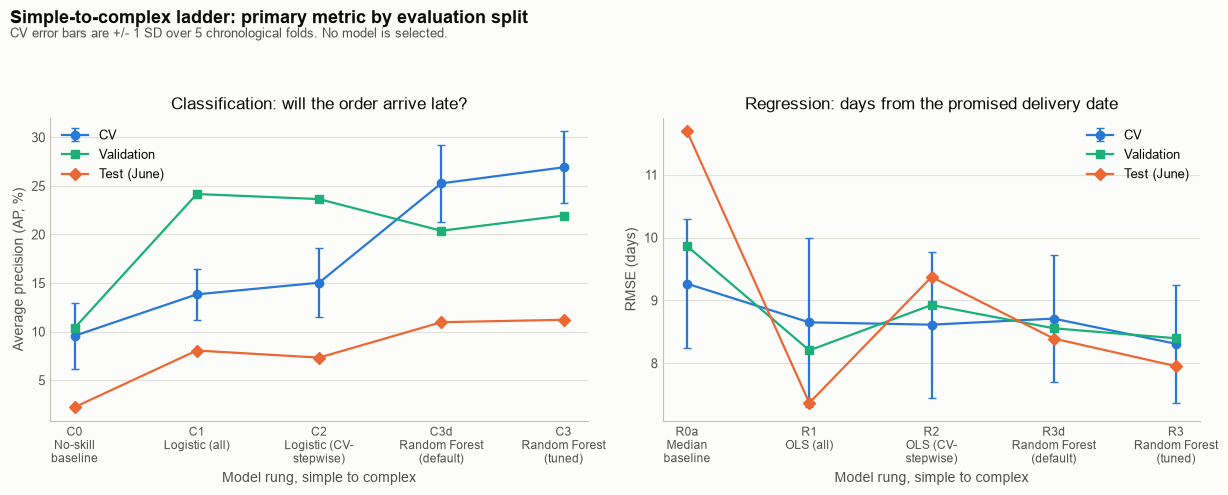

In [3]:
for task in tasks:
    display(Markdown(f'**{task.spec.title}** ({task.spec.metric_label})\n\n' + sm.ladder_markdown_table(task)))
sm.plot_ladder(tasks, FIG / '04_ladder.png')
plt.show()

## 4. Overfitting gaps

Train minus CV mean for the primary metric. A large gap means the model fits Train much better than later folds, as the default forests do.

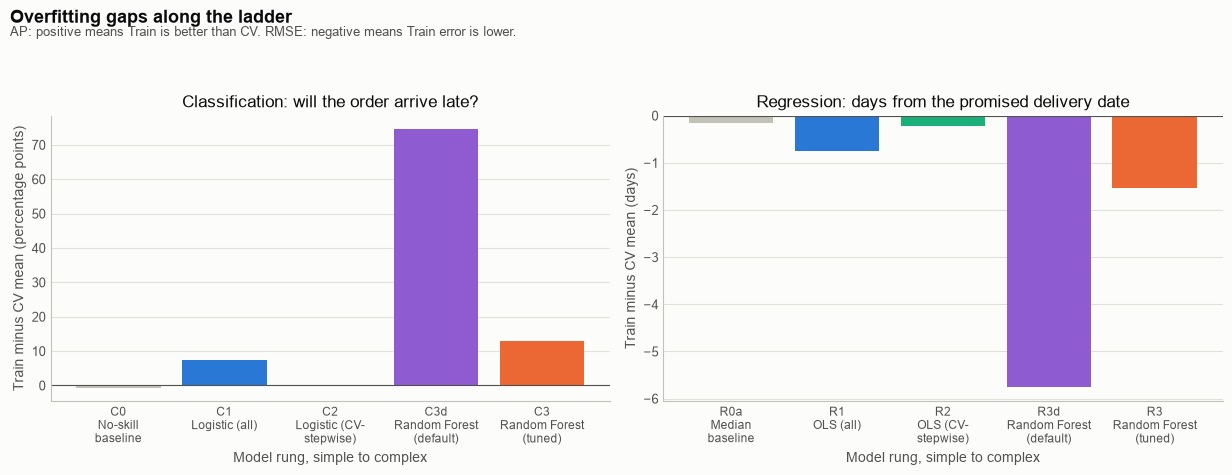

In [4]:
sm.plot_overfitting_gaps(tasks, FIG / '04_overfitting_gaps.png')
plt.show()

## 5. Drift from June to August

Frozen June models are scored on July and August without refitting. The top row shows the primary metric by month; the bottom row shows the change from June to August. Late rates differ by month, so the baselines move too.

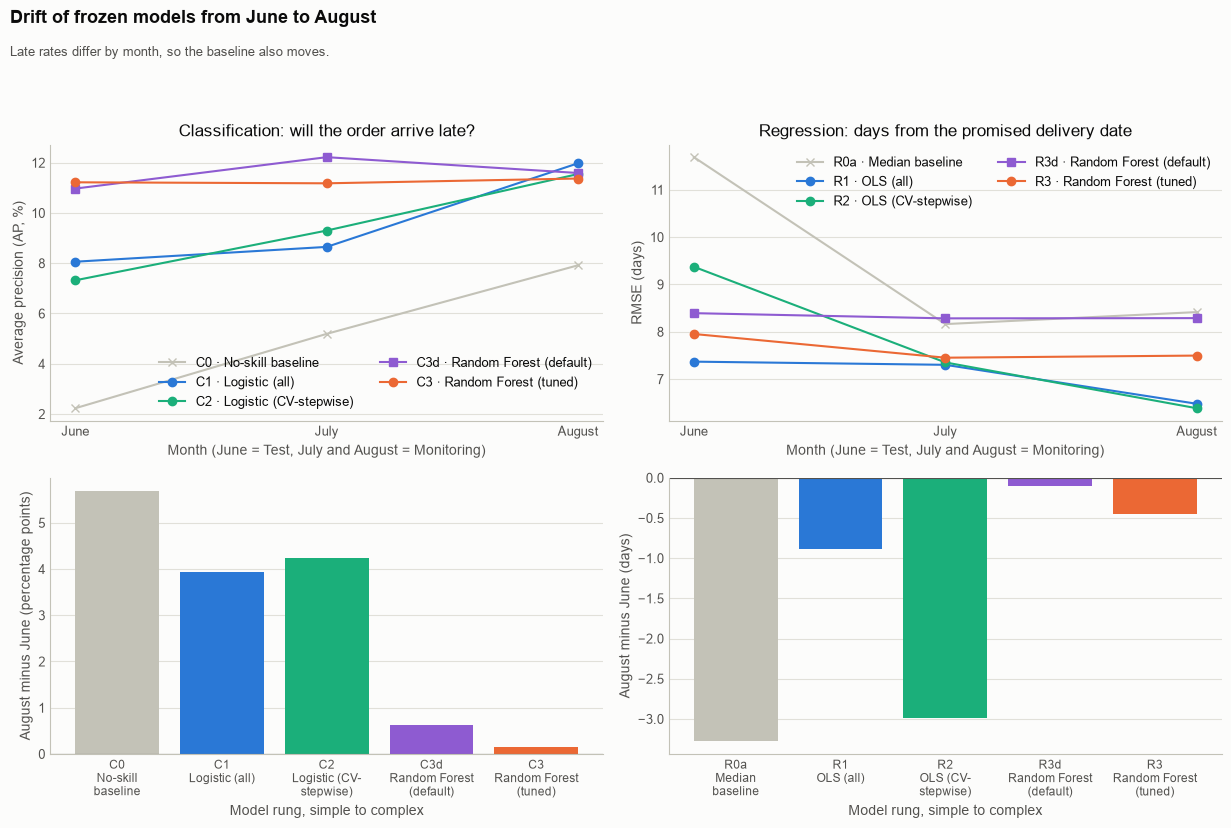

In [5]:
sm.plot_drift_summary(tasks, FIG / '04_drift_summary.png')
plt.show()

## 6. Write the summary and merged metadata

`build_summary` regenerates the three figures above, writes `RESULTS_SUMMARY.md` (every number is read from the exports) and writes `run_metadata.json` with both tasks and the package versions.

In [6]:
paths = sm.build_summary(ROOT)
for key, path in paths.items():
    print(f'{key}: {path}')
print(sm.merge_metadata(tasks)['package_versions'])

ladder: results/simple_to_complex/figures/04_ladder.png
gaps: results/simple_to_complex/figures/04_overfitting_gaps.png
drift: results/simple_to_complex/figures/04_drift_summary.png
summary: results/simple_to_complex/RESULTS_SUMMARY.md
metadata: results/simple_to_complex/run_metadata.json
{'python': '3.13.5', 'scikit-learn': '1.9.1', 'numpy': '2.5.3', 'pandas': '3.0.6', 'statsmodels': '0.15.0', 'imbalanced-learn': '0.14.2'}
